[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/adaptive-intelligent-robotics/QDax/blob/main/examples/mtme.ipynb)

# Optimizing multiple tasks with Multi-task MAP-Elites in JAX

This notebook shows how to use QDax to solve many tasks of the same family simultaneously with [Multi-task MAP-Elites](https://arxiv.org/abs/2003.04407) (MT-ME). We reproduce the first experiment of the paper: a 10-DoF planar arm with a parameterized morphology, where each of the 5000 tasks is a different morphology (total length of the arm and joint limits) and the goal is to find, for every morphology, the joint angles that bring the end-effector as close as possible to a fixed target.

In Multi-task MAP-Elites, each cell of the repertoire corresponds to a task and stores the best solution found so far for this task. The task on which an offspring is evaluated is selected with a tournament biased towards the task of its first parent, and the size of the tournament is adjusted on the fly with a UCB1 multi-armed bandit. This notebook shows:

- how to define a set of tasks and a task-conditioned scoring function
- how to create an emitter that exposes the descriptors of the parents
- how to create a Multi-task MAP-Elites instance
- how to launch a certain number of training steps
- how to visualise the resulting map of solutions and the behavior of the bandit

## Installation

You will need Python 3.11 or later, and a working JAX installation. For example, you can install JAX with:

In [30]:
%pip install -U "jax[cuda]"

/Users/mac/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


/Users/mac/Data/QDax/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


Then, install QDax from PyPI:

In [31]:
%pip install -U "qdax[examples]"

/Users/mac/Data/QDax/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [32]:
import functools

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from qdax.core.containers.mapelites_repertoire import compute_cvt_centroids
from qdax.core.emitters.mtme_emitter import MultiTaskMixingEmitter
from qdax.core.emitters.mutation_operators import isoline_variation
from qdax.core.mtme import MultiTaskMAPElites
from qdax.tasks.arm import multi_task_arm_scoring_function
from qdax.utils.metrics import default_qd_metrics
from qdax.utils.plotting import plot_map_elites_results

In [33]:
#@title QD Training Definitions Fields
#@markdown ---
seed = 42 #@param {type:"integer"}
num_param_dimensions = 10 #@param {type:"integer"}
num_tasks = 5000 #@param {type:"integer"}
batch_size = 64 #@param {type:"integer"}
num_iterations = 15625 #@param {type:"integer"}
iso_sigma = 0.005 #@param {type:"number"}
line_sigma = 0.05 #@param {type:"number"}
tournament_sizes = (1, 5, 10, 100) #@param {type:"raw"}
num_init_cvt_samples = 50000 #@param {type:"integer"}
min_task_descriptor = 0.0 #@param {type:"number"}
max_task_descriptor = 1.0 #@param {type:"number"}
target = (0.5, 0.5) #@param {type:"raw"}
#@markdown ---

## Define the tasks

A task is a morphology of the arm, described by a 2-dimensional task descriptor: the total length of the arm and the maximum angle of its joints, both normalized. As in the paper, the tasks are spread evenly in the task space with a centroidal Voronoi tessellation (they could also have been spread randomly or on a grid). The task descriptors play the role of the centroids of the repertoire.

The scoring function evaluates each genotype (the joint angles) on the morphology described by the task descriptor it is given, and returns the negative distance between the end-effector and the target. Note: the text of the paper mentions a target of (1, 1), but the reference implementation of the paper uses (0.5, 0.5), which is what reproduces the published results (a mean fitness over the map of about -0.35 after 1 million evaluations); we hence use (0.5, 0.5) here.

In [34]:
key = jax.random.key(seed)

# compute the task descriptors (the centroids of the repertoire)
key, subkey = jax.random.split(key)
task_descriptors = compute_cvt_centroids(
    num_descriptors=2,  # (total arm length, max joint angle)
    num_init_cvt_samples=num_init_cvt_samples,
    num_centroids=num_tasks,
    minval=min_task_descriptor,
    maxval=max_task_descriptor,
    key=subkey,
)

# task-conditioned scoring function, with the target used in the reference
# implementation of the paper
scoring_fn = functools.partial(multi_task_arm_scoring_function, target=target)

## Define the emitter and instantiate Multi-task MAP-Elites

The offsprings are generated with the iso+line variation operator. The task-selection tournament needs to know the task of the first parent of each offspring, hence we use the `MultiTaskMixingEmitter`, which returns the descriptors of the parents in its extra information. To use plain uniform task selection (the "random task" variant of the paper), one can pass `tournament_sizes=(1,)` and use any emitter.

In [35]:
# define the emitter
variation_fn = functools.partial(
    isoline_variation,
    iso_sigma=iso_sigma,
    line_sigma=line_sigma,
)
emitter = MultiTaskMixingEmitter(
    mutation_fn=lambda x, y: x,
    variation_fn=variation_fn,
    variation_percentage=1.0,
    batch_size=batch_size,
)

# define a metrics function; the fitness is the negative distance to the
# target, which is bounded below by -(sqrt(2)/2 + 1) in the task space considered
metrics_fn = functools.partial(default_qd_metrics, qd_offset=jnp.sqrt(2) / 2 + 1)

# instantiate Multi-task MAP-Elites
mtme = MultiTaskMAPElites(
    scoring_function=scoring_fn,
    emitter=emitter,
    metrics_function=metrics_fn,
    tournament_sizes=tournament_sizes,
)

In [36]:
# initial population of random joint angles in [0, 1]
key, subkey = jax.random.split(key)
init_genotypes = jax.random.uniform(
    subkey,
    shape=(batch_size, num_param_dimensions),
    minval=0.0,
    maxval=1.0,
)

# initialize the repertoire, the emitter state and the bandit state
key, subkey = jax.random.split(key)
repertoire, emitter_state, mtme_state, init_metrics = mtme.init(
    init_genotypes, task_descriptors, subkey
)

## Launch Multi-task MAP-Elites iterations

In [37]:
(
    repertoire,
    emitter_state,
    mtme_state,
    key,
), metrics = jax.lax.scan(
    mtme.scan_update,
    (repertoire, emitter_state, mtme_state, key),
    (),
    length=num_iterations,
)

occupied = repertoire.fitnesses[:, 0] != -jnp.inf
print(f"Tasks with a solution: {int(jnp.sum(occupied))} / {num_tasks}")
print(f"Mean fitness over the map: {float(jnp.mean(repertoire.fitnesses[occupied, 0])):.4f}")

Tasks with a solution: 5000 / 5000
Mean fitness over the map: -0.3335


## Visualise the results

The map below shows the fitness of the best solution found for each task: each cell of the map is a morphology of the arm (its total length on the x-axis and its maximum joint angle on the y-axis) and the color is the negative distance between the end-effector and the target. Arms that are long and flexible enough can reach the target exactly, while short arms fall short of it by construction, hence the fitness gradient over the task space.

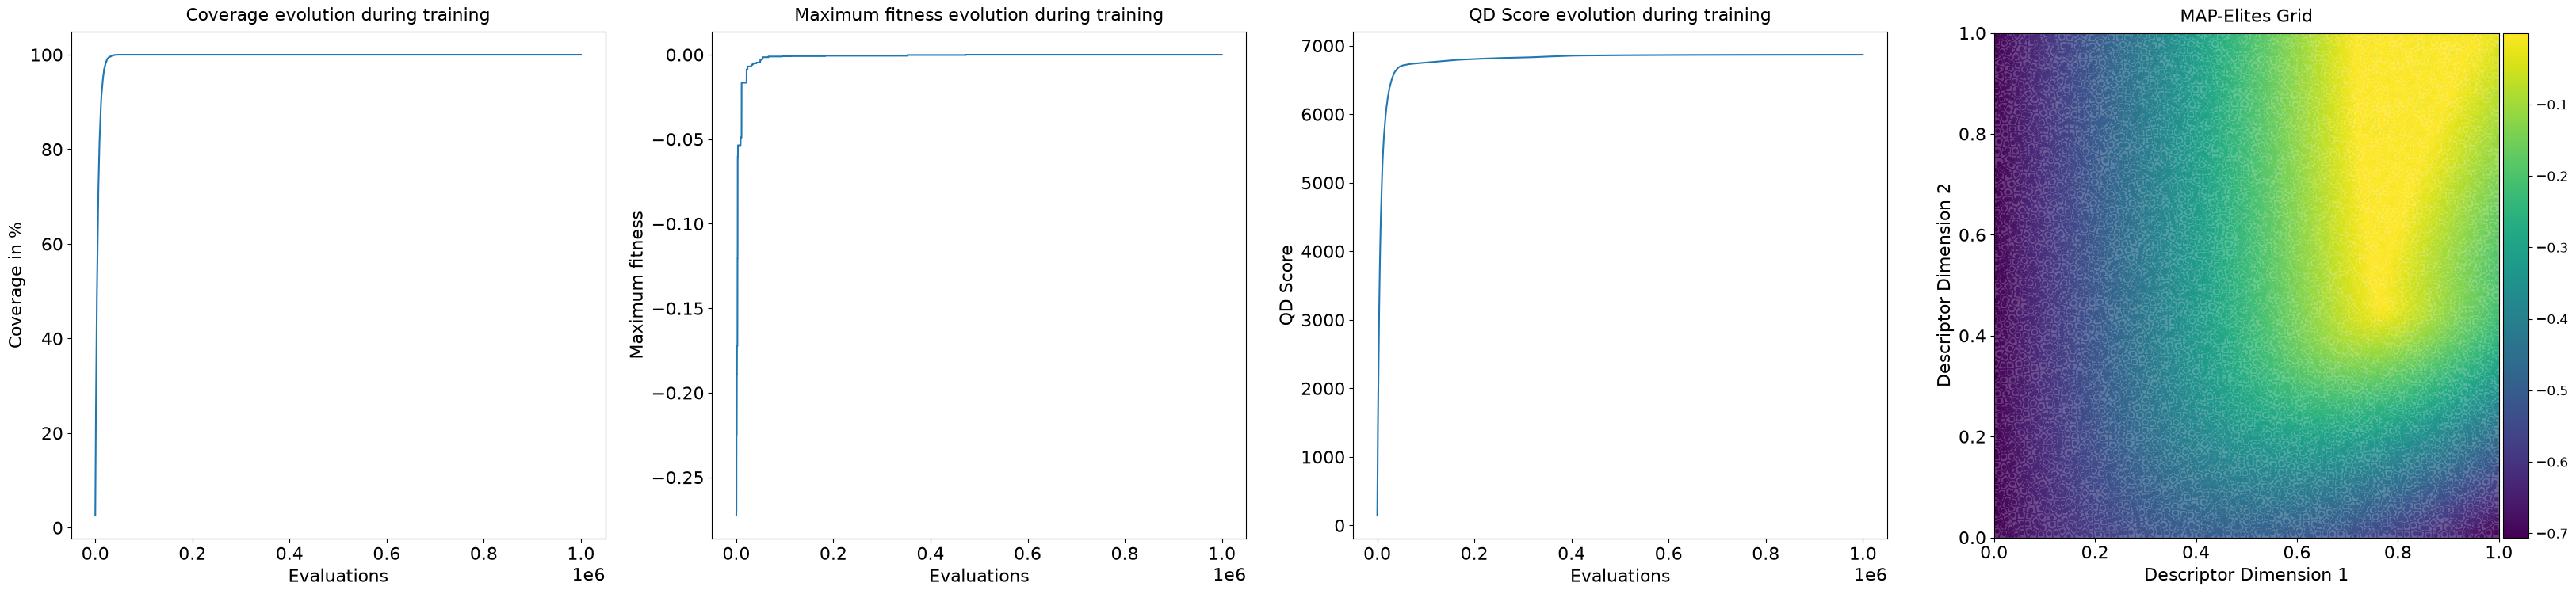

In [38]:
# create the x-axis array: each iteration evaluates batch_size offsprings
evaluations = jnp.arange(1, num_iterations + 1) * batch_size

# create the plots and the grid
fig, axes = plot_map_elites_results(
    env_steps=evaluations,
    metrics=metrics,
    repertoire=repertoire,
    min_descriptor=min_task_descriptor,
    max_descriptor=max_task_descriptor,
    x_label="Evaluations",
)

## Inspect the task-selection bandit

The UCB1 bandit adjusts the size of the task-selection tournament on the fly, using the number of offsprings added to the repertoire as the reward. We can inspect how often each tournament size has been selected and its success rate.

In [39]:
print(f"{'Tournament size':>16} {'Selected':>10} {'Successes':>10} {'Success rate':>14}")
for size, selected, successes in zip(
    tournament_sizes, mtme_state.selection_counts, mtme_state.success_counts
):
    rate = float(successes) / (float(selected) * batch_size) if selected > 0 else 0.0
    print(f"{size:>16} {int(selected):>10} {int(successes):>10} {rate:>13.1%}")

 Tournament size   Selected  Successes   Success rate
               1        478       4749         15.5%
               5       1070      10719         15.7%
              10       1478      14835         15.7%
             100      12599     127468         15.8%
